# ESID4HPO — semantic content & LIRICAL evaluation

**Goal.** Quantify what the ESID/HPO workshop added to the ontology by comparing patient
annotations expressed with two HPO releases:

| role | release | how it is obtained |
|------|---------|--------------------|
| **old** (before workshop) | `v2024-08-13` | phenopackets are *aged* down to this vocabulary |
| **new** (after workshop)  | `v2026-06-23` | phenopackets as curated |

The cohorts are curated from primary literature and annotated with the **new** HPO.
We run two analyses and produce per-cohort and cross-cohort summary figures:

1. **Semantic content** — information content (IC) / specificity carried by the annotations,
   number of terms per patient, and the footprint of post-workshop terms.
2. **LIRICAL** — rank of the causal disease before vs. after, run via the `lirical benchmark`
   command with version-matched data bundles.

Everything is driven by a `COHORTS` list and small reusable functions, so the same run is
replicated for **SOCS1**, **APDS** and **NFKB1** by editing one config cell.

> Built on the structure of *Evaluate utility of new annotations in Netherton.ipynb*.

## 0  Setup & configuration

In [1]:
import os
import math
import pathlib
import typing
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import hpotk
from google.protobuf.json_format import Parse, MessageToJson
from phenopackets.schema.v2.phenopackets_pb2 import Phenopacket
from phenopackets.schema.v2.core.base_pb2 import OntologyClass
from phenopackets.schema.v2.core.phenotypic_feature_pb2 import PhenotypicFeature

try:
    from scipy.stats import wilcoxon
    HAVE_SCIPY = True
except Exception:
    HAVE_SCIPY = False
    print("scipy not available - paired significance tests will be skipped")

### Paths

The notebook lives in `src/analysis/`. Cohorts are under `src/cohorts/<NAME>/phenopackets/`.
Outputs (aged phenopackets, LIRICAL inputs, figures) go under `src/analysis/_work/`.

In [2]:
FPATH_NB   = pathlib.Path(os.getcwd())                 # .../src/analysis
FPATH_SRC  = FPATH_NB.parent                           # .../src
FPATH_COH  = FPATH_SRC / "cohorts"                     # .../src/cohorts
FPATH_WORK = FPATH_NB / "_work"                         # scratch + outputs
FPATH_FIGS = FPATH_WORK / "figures"
FPATH_LIRICAL = FPATH_WORK / "lirical"                 # LIRICAL inputs/outputs
for p in (FPATH_WORK, FPATH_FIGS, FPATH_LIRICAL):
    p.mkdir(parents=True, exist_ok=True)
FPATH_COH

PosixPath('/Users/adamgraefe/Documents/git/esid4hpo-analysis/src/cohorts')

### Cohorts

Add a cohort by dropping phenopackets in `src/cohorts/<NAME>/phenopackets/` and adding a row
here. `disease_id` is only used for labelling — LIRICAL determines the causal disease itself
(`is_causal` column of the benchmark output).

> ⚠️ Confirm the OMIM IDs for APDS / NFKB1 before quoting them in the manuscript. The values
> below are the commonly used ones; SOCS1 (`OMIM:619375`, AISIMD) is taken from the phenopackets.

In [3]:
@dataclass(frozen=True)
class Cohort:
    name: str
    disease_id: str
    disease_label: str
    color: str
    pp_subdir: str = "phenopackets"

    def pp_dir(self, root: pathlib.Path = FPATH_COH) -> pathlib.Path:
        return root / self.name / self.pp_subdir


COHORTS = [
    Cohort("SOCS1", "OMIM:619375",
           "Autoinflammatory syndrome, familial, with or without immunodeficiency",
           color="#2b6cb0"),
    # --- fill in once phenopackets are added -----------------------------------
    Cohort("APDS",  "OMIM:615513",   # APDS1/PIK3CD; APDS2/PIK3R1 = OMIM:616005 (confirm!)
           "Activated PI3K-delta syndrome", color="#dd6b20"),
    Cohort("NFKB1", "OMIM:616576",   # CVID12 / NFKB1 haploinsufficiency (confirm!)
           "Common variable immunodeficiency 12 (NFKB1)", color="#38a169"),
]


# keep only cohorts that actually have phenopackets on disk today
ACTIVE = [c for c in COHORTS if c.pp_dir().is_dir() and any(c.pp_dir().glob("*.json"))]
print("Active cohorts:", [c.name for c in ACTIVE])
for c in COHORTS:
    n = len(list(c.pp_dir().glob("*.json"))) if c.pp_dir().is_dir() else 0
    print(f"  {c.name:6s} {n:3d} phenopackets   {c.pp_dir()}")

Active cohorts: ['SOCS1', 'APDS', 'NFKB1']
  SOCS1   28 phenopackets   /Users/adamgraefe/Documents/git/esid4hpo-analysis/src/cohorts/SOCS1/phenopackets
  APDS    38 phenopackets   /Users/adamgraefe/Documents/git/esid4hpo-analysis/src/cohorts/APDS/phenopackets
  NFKB1   21 phenopackets   /Users/adamgraefe/Documents/git/esid4hpo-analysis/src/cohorts/NFKB1/phenopackets


### HPO releases

On a machine with internet access both releases are pulled from the HPO ontology store.
If you already have the JSON locally (e.g. an unreleased build), pass a path instead.

In [4]:
HPO_OLD_TAG = "v2024-08-13"   # before the ESID4HPO workshop
HPO_NEW_TAG = "v2026-06-23"   # workshop release


def load_hpo(tag: str | None = None, path: str | pathlib.Path | None = None):
    """Load a MinimalOntology from the ontology store (by tag) or from a local json."""
    if path is not None:
        print(f"Loading HPO from {path}")
        return hpotk.load_minimal_ontology(str(path))
    store = hpotk.configure_ontology_store()
    return store.load_minimal_hpo(release=tag)


hpo_old = load_hpo(tag=HPO_OLD_TAG)
hpo_new = load_hpo(tag=HPO_NEW_TAG)
print("old:", hpo_old.version, " | new:", hpo_new.version)

old: 2024-08-13  | new: 2026-06-23


## 1  Core functions

Everything below is plain functions so you can tweak thresholds, the IC definition or the
figure styling without touching the analysis flow.

### 1.1  Reading phenopackets

In [5]:
def load_phenopackets(ppdir: pathlib.Path) -> list[tuple[str, Phenopacket]]:
    """Return [(filename, Phenopacket), ...] sorted by filename."""
    out = []
    for fp in sorted(ppdir.glob("*.json")):
        with fp.open() as fh:
            out.append((fp.name, Parse(fh.read(), Phenopacket())))
    return out


def feature_pairs(pp: Phenopacket, include_excluded: bool = True) -> list[tuple[str, bool]]:
    """(CURIE, excluded) for each phenotypic feature, de-duplicated, order preserved."""
    out, seen = [], set()
    for pf in pp.phenotypic_features:
        if pf.excluded and not include_excluded:
            continue
        key = (pf.type.id, pf.excluded)
        if key not in seen:
            seen.add(key); out.append(key)
    return out


def feature_curies(pp: Phenopacket, include_excluded: bool = True) -> list[str]:
    """Convenience: just the CURIEs (any status)."""
    return [c for c, _ in feature_pairs(pp, include_excluded)]

### 1.2  Aging annotations to the old vocabulary

Each term absent from the old release is replaced by its **nearest ancestor that exists in the
old release** (breadth-first over `is_a` parents in the new graph). Terms already present in
old HPO are kept. This mirrors `generalize_hpo_set` from the Netherton notebook, with a `seen`
guard for the multi-parent DAG. Several new terms can collapse onto one old ancestor — that
loss of resolution is exactly what we want to measure.

**Excluded findings are handled separately.** A negated specific term cannot be moved up the
hierarchy (excluding *Decreased CD8+ TEMRA proportion* does not justify excluding *Abnormal
total T cell number*). Excluded features are kept only if directly representable in the old
release; otherwise they are dropped. Toggle `generalize_excluded=True` to override.

In [6]:
def generalize_term(curie: str, hpo_old, hpo_new) -> str | None:
    """Nearest ancestor (incl. self) of `curie` present in `hpo_old`; None if untraceable."""
    if curie in hpo_old:
        return curie
    if curie not in hpo_new:
        return None
    seen: set[str] = set()
    stack = list(hpo_new.graph.get_parents(curie))
    while stack:
        cur = stack.pop()
        if cur.value in seen:
            continue
        seen.add(cur.value)
        if cur in hpo_old:
            return cur.value
        stack.extend(hpo_new.graph.get_parents(cur))
    return None


def age_curies(curies: typing.Iterable[str], hpo_old, hpo_new) -> list[str]:
    """Age a set of CURIEs to the old vocabulary, de-duplicated, order preserved."""
    seen: set[str] = set()
    out: list[str] = []
    for c in curies:
        g = generalize_term(c, hpo_old, hpo_new)
        if g is not None and g not in seen:
            seen.add(g)
            out.append(g)
    return out


def age_feature(curie: str, excluded: bool, hpo_old, hpo_new,
                generalize_excluded: bool = False) -> str | None:
    """Age a single feature respecting its negation status.

    Observed findings generalize up to the nearest old-HPO ancestor. *Excluded* findings are
    NOT generalized by default: excluding a specific term does not license excluding its
    parent (that would assert the absence of every sibling too). An excluded finding therefore
    survives only if it is directly representable in the old release, otherwise it is dropped -
    which correctly captures negative information that the old vocabulary could not express.
    """
    if excluded and not generalize_excluded:
        return curie if curie in hpo_old else None
    return generalize_term(curie, hpo_old, hpo_new)

### 1.3  Information content (specificity)

Set by `IC_METHOD` in section 2. Four options, all exposing the same
`ic(curie) -> float | None` interface.

**`"hpoa"` (primary).** Resnik IC over the **disease corpus**:
`IC(t) = -ln p(t)`, `p(t) = freq(t)/N`, where `freq(t)` counts *diseases* annotated to
`t` or to any descendant of `t`, and `N` is the number of diseases in `phenotype.hpoa`.
This is the diagnostic framing - how much a term narrows the differential across all
known diseases. It requires the **augmented** HPOA
(`_work/hpoa_adjusted/new/phenotype_augmented.hpoa`), because in the stock release the
annotation lines for our three diseases are byte-identical between v2024-08-13 and
v2026-06-23 - the workshop terms have zero annotated diseases and their IC is undefined.

> **Circularity.** A workshop term reaches near-maximal IC largely because *we* just
> annotated it, to 1-2 diseases out of ~13,000. The effect is arithmetically correct but
> partly self-inflicted, and must be stated in the Methods. `IC_METHOD = "hpoa_loo"`
> scores each patient against an HPOA excluding its own source PMID, which breaks the
> loop. That does not violate the frozen-table rule: both arms of a given patient still
> share one table.

**`"cohort"`.** Resnik IC with frequencies from the cohort's own patients - cohort-internal
specificity rather than cross-disease specificity. A different quantity, worth reporting
alongside rather than instead. Normalised by `ln(n)`, without which APDS (n=38) out-scores
SOCS1 (n=28) for purely arithmetic reasons.

> **Caveat.** Under a cohort corpus a term carried by *every* patient has `p = 1` and so
> `IC = 0`, in both arms: a pathognomonic workshop term contributes **zero** measured gain.
> The diagnostic cell in section 2 prints the affected terms.

> **Note on direction.** Every IC definition here is monotone non-increasing toward the
> root, so ageing can never *increase* IC. The Wilcoxon test asks whether the collapse is
> non-trivial, not whether it points the right way. State this in the Methods.

**`"intrinsic"` (original figure).** Structural IC (Seco *et al.* 2004) — derived from the ontology structure alone, so it
needs no annotation corpus and is fully reproducible from the two `hp.json` files:

$$\mathrm{IC}(t) = 1 - \frac{\ln\big(|\mathrm{desc}(t)| + 1\big)}{\ln N}$$

where $|\mathrm{desc}(t)|$ counts descendants of $t$ and $N$ is the number of classes under
*Phenotypic abnormality*. Leaves → IC ≈ 1 (most specific), the root → 0.

Both the **new** and the **aged** term sets are scored on a **single fixed yardstick** (the new
ontology) so the comparison isolates *which term was chosen*, not how the graph was re-shaped.

> *Alternative.* For annotation-based Resnik IC, replace `build_intrinsic_ic` with a function
> that reads term frequencies from the version-matched `phenotype.hpoa`. The downstream code
> only needs a callable `ic(curie) -> float | None`.

In [7]:
def build_intrinsic_ic(hpo, root: str = "HP:0000118"):
    """Return ic(curie)->float|None using intrinsic IC on a fixed ontology."""
    N = sum(1 for _ in hpo.graph.get_descendants(root, include_source=True))
    log_n = math.log(N)
    cache: dict[str, float] = {}

    def ic(curie: str) -> float | None:
        if curie not in hpo:
            return None
        if curie in cache:
            return cache[curie]
        n_desc = sum(1 for _ in hpo.graph.get_descendants(curie, include_source=True))
        val = 1.0 - math.log(n_desc) / log_n
        cache[curie] = val
        return val

    ic.N = N            # type: ignore[attr-defined]
    ic.ontology = hpo   # type: ignore[attr-defined]
    return ic


def cohort_curie_sets(cohort, hpo_old, hpo_new, include_excluded: bool = True):
    """One set of directly-annotated CURIEs per patient (union of both arms).

    The union guarantees every scored term has frequency >= 1 in the corpus,
    so no smoothing is needed. Under pure ancestor-ageing the union equals the
    curated arm alone, so this costs nothing and is robust to dropped
    excluded features.
    """
    ents = []
    for _, pp in load_phenopackets(cohort.pp_dir()):
        pairs = feature_pairs(pp, include_excluded)
        new_c = {c for c, _ in pairs}
        aged_c = set()
        for c, exc in pairs:
            g = age_feature(c, exc, hpo_old, hpo_new)
            if g is not None:
                aged_c.add(g)
        ents.append(new_c | aged_c)
    return ents


def build_cohort_ic(entity_curie_sets, hpo, root: str = "HP:0000118",
                    normalize: bool = True):
    """Resnik IC with term frequencies taken from THE COHORT ITSELF.

    IC(t) = -ln p(t),  p(t) = freq(t) / n, where freq(t) counts corpus
    patients annotated to t OR to any descendant of t (true-path propagation
    via ancestor closure of each patient's direct annotations).

    normalize divides by ln(n) -> IC on [0, 1]. REQUIRED when cohorts of
    different size are compared: raw Resnik IC scales with ln(n), so APDS
    (n=38) would out-score SOCS1 (n=28) for purely arithmetic reasons.

    Build ONE model per cohort and score BOTH arms with it. A separate table
    per arm would put the arms in different probability spaces and the IC
    difference would stop being interpretable.
    """
    n = len(entity_curie_sets)
    if n == 0:
        raise ValueError("empty corpus")

    anc_cache: dict[str, set[str]] = {}

    def ancestors(curie: str) -> set[str]:
        if curie in anc_cache:
            return anc_cache[curie]
        if curie not in hpo:
            anc_cache[curie] = set()
            return anc_cache[curie]
        anc = {a.value for a in hpo.graph.get_ancestors(curie)}
        anc.add(curie)
        anc = {a for a in anc if a == root or root in
               {x.value for x in hpo.graph.get_ancestors(a)} or a == curie and curie == root}
        anc_cache[curie] = anc
        return anc

    freq: dict[str, int] = {}
    for terms in entity_curie_sets:
        expanded: set[str] = set()
        for c in terms:
            expanded |= ancestors(c)
        for t in expanded:
            freq[t] = freq.get(t, 0) + 1

    max_ic = math.log(n) if n > 1 else 1.0
    table: dict[str, float] = {}
    for t, f in freq.items():
        val = -math.log(min(f / n, 1.0))
        table[t] = val / max_ic if (normalize and max_ic > 0) else val

    def ic(curie: str) -> float | None:
        return table.get(curie)

    ic.N = n                 # type: ignore[attr-defined]
    ic.freq = freq           # type: ignore[attr-defined]
    ic.table = table         # type: ignore[attr-defined]
    ic.normalized = normalize  # type: ignore[attr-defined]
    ic.ontology = hpo        # type: ignore[attr-defined]
    return ic


# --- HPOA-based (cross-disease) Resnik IC ----------------------------------
import csv, re


def make_ancestor_fn(hpo, root: str = "HP:0000118"):
    """Cached ancestor closure restricted to the `root` subtree."""
    cache: dict[str, set[str]] = {}

    def ancestors(curie: str) -> set[str]:
        hit = cache.get(curie)
        if hit is not None:
            return hit
        if curie not in hpo:
            cache[curie] = set()
            return cache[curie]
        anc = {a.value for a in hpo.graph.get_ancestors(curie)}
        anc.add(curie)
        anc = anc if (root in anc or curie == root) else set()
        cache[curie] = anc
        return anc

    return ancestors


def resnik_table(entity_term_sets, ancestors, normalize: bool = True):
    """IC(t) = -ln(freq(t)/n), freq counted over entities with ancestor closure."""
    n = len(entity_term_sets)
    if n == 0:
        raise ValueError("empty corpus")
    freq: dict[str, int] = {}
    for terms in entity_term_sets:
        expanded: set[str] = set()
        for c in terms:
            expanded |= ancestors(c)
        for t in expanded:
            freq[t] = freq.get(t, 0) + 1
    mx = math.log(n) if n > 1 else 1.0
    table = {t: (-math.log(min(f / n, 1.0))) / (mx if normalize else 1.0)
             for t, f in freq.items()}
    return table, freq, n


def load_hpoa_disease_terms(path, aspect: str = "P", drop_negated: bool = True,
                            only: set[str] | None = None) -> dict[str, set[str]]:
    """Parse a phenotype.hpoa into {disease_id: {hpo_curie, ...}}."""
    out: dict[str, set[str]] = {}
    with open(path, encoding="utf-8") as fh:
        rows = (ln for ln in fh if not ln.startswith("#"))
        for r in csv.DictReader(rows, delimiter="\t"):
            if aspect and r.get("aspect") != aspect:
                continue
            if drop_negated and (r.get("qualifier") or "").strip().upper() == "NOT":
                continue
            db, hp = r.get("database_id"), r.get("hpo_id")
            if not db or not hp:
                continue
            if only is not None and db not in only:
                continue
            out.setdefault(db, set()).add(hp)
    return out


def build_hpoa_ic(disease_terms, hpo, root: str = "HP:0000118",
                  normalize: bool = True):
    """Resnik IC over the disease corpus: freq(t) = number of DISEASES annotated
    to t or to any descendant of t. This is Peter's "IC with respect to all
    HPOAs" - the diagnostic framing. Requires the augmented HPOA, otherwise the
    workshop terms have zero annotated diseases and IC is undefined.
    """
    ancestors = make_ancestor_fn(hpo, root)
    table, freq, n = resnik_table(list(disease_terms.values()), ancestors, normalize)

    def ic(curie: str) -> float | None:
        return table.get(curie)

    ic.N = n              # type: ignore[attr-defined]
    ic.freq = freq        # type: ignore[attr-defined]
    ic.table = table      # type: ignore[attr-defined]
    ic.ontology = hpo     # type: ignore[attr-defined]
    return ic


class HpoaLooIC:
    """Leave-one-PMID-out HPOA IC.

    A workshop term reaches near-maximal IC partly because WE just annotated it
    to one disease. Scoring each patient against an HPOA that excludes its own
    source publication breaks that circularity. This does not violate the
    frozen-table rule: both arms of a given patient still share one table.

    Only the cohort diseases differ between the per-PMID files, so the base
    corpus is parsed once and only those diseases are swapped per PMID.
    """

    def __init__(self, base_path, loo_dir, cohort_disease_ids, hpo,
                 root="HP:0000118", normalize=True):
        self.hpo, self.root, self.normalize = hpo, root, normalize
        self.ancestors = make_ancestor_fn(hpo, root)
        self.base = load_hpoa_disease_terms(base_path)
        self.cohort_ids = set(cohort_disease_ids)
        self.loo_dir = pathlib.Path(loo_dir)
        self._tables: dict[str, dict] = {}
        self._active = self._table_for(None)

    def _table_for(self, pmid):
        key = pmid or "__full__"
        if key in self._tables:
            return self._tables[key]
        terms = dict(self.base)
        if pmid:
            f = self.loo_dir / f"phenotype_PMID_{pmid}.hpoa"
            if f.exists():
                swap = load_hpoa_disease_terms(f, only=self.cohort_ids)
                for d in self.cohort_ids:
                    if d in swap:
                        terms[d] = swap[d]
                    else:
                        terms.pop(d, None)
            else:
                print(f"    [warn] no LOO file for PMID:{pmid}, using full corpus")
        tbl, _, _ = resnik_table(list(terms.values()), self.ancestors, self.normalize)
        self._tables[key] = tbl
        return tbl

    def set_context(self, fname: str):
        m = re.search("PMID[_:]?([0-9]+)", str(fname))
        self._active = self._table_for(m.group(1) if m else None)

    def __call__(self, curie: str):
        return self._active.get(curie)

### 1.4  Per-cohort semantic table

In [8]:
def semantic_tables(cohort: Cohort, hpo_old, hpo_new, ic,
                    include_excluded: bool = True):
    """Return (df_patient, df_terms) for one cohort.

    df_patient : one row / phenopacket with term counts and IC summaries (new vs aged).
    df_terms   : long form, one row / (phenopacket, term, version) with its IC.
    """
    prows, trows = [], []
    for fname, pp in load_phenopackets(cohort.pp_dir()):
        if hasattr(ic, "set_context"):
            ic.set_context(fname)   # leave-one-PMID-out: swap the active table
        pairs = feature_pairs(pp, include_excluded)
        new_curies = list(dict.fromkeys(c for c, _ in pairs))
        aged_seen, aged_curies = set(), []
        for c, exc in pairs:
            g = age_feature(c, exc, hpo_old, hpo_new)
            if g is not None and g not in aged_seen:
                aged_seen.add(g); aged_curies.append(g)

        new_ic  = [ic(c) for c in new_curies  if ic(c) is not None]
        aged_ic = [ic(c) for c in aged_curies if ic(c) is not None]
        n_newly = sum(1 for c in new_curies if c not in hpo_old)

        prows.append(dict(
            cohort=cohort.name, phenopacket=fname,
            n_new=len(new_curies), n_aged=len(aged_curies),
            ic_new=float(np.sum(new_ic)),  ic_aged=float(np.sum(aged_ic)),
            mean_ic_new=float(np.mean(new_ic))  if new_ic  else np.nan,
            mean_ic_aged=float(np.mean(aged_ic)) if aged_ic else np.nan,
            n_newly_enabled=n_newly,
            frac_newly_enabled=n_newly / len(new_curies) if new_curies else np.nan,
        ))
        for c in new_curies:
            if ic(c) is not None:
                trows.append(dict(cohort=cohort.name, phenopacket=fname,
                                  version="new", curie=c, ic=ic(c)))
        for c in aged_curies:
            if ic(c) is not None:
                trows.append(dict(cohort=cohort.name, phenopacket=fname,
                                  version="old", curie=c, ic=ic(c)))
    return pd.DataFrame(prows), pd.DataFrame(trows)

### 1.5  LIRICAL benchmark I/O

In [9]:
def load_lirical_ranks(csv_path: pathlib.Path) -> pd.DataFrame:
    """Causal-disease rank per phenopacket from a `lirical benchmark` CSV."""
    df = pd.read_csv(csv_path)
    causal = df.loc[df["is_causal"], ["phenopacket", "rank", "post_test_proba"]]
    return causal.set_index("phenopacket").sort_index()


def lirical_rank_table(old_csv, new_csv,
                       old_label="old", new_label="new") -> pd.DataFrame:
    """Wide table: index=phenopacket, columns=[old_label, new_label] of causal rank."""
    old = load_lirical_ranks(pathlib.Path(old_csv))["rank"].rename(old_label)
    new = load_lirical_ranks(pathlib.Path(new_csv))["rank"].rename(new_label)
    return pd.concat([old, new], axis=1)

### 1.6  Figure styling

In [10]:
def set_style():
    mpl.rcParams.update({
        "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
        "font.size": 11, "font.family": "DejaVu Sans",
        "axes.titlesize": 12, "axes.titleweight": "bold", "axes.labelsize": 11,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
        "legend.frameon": False, "legend.fontsize": 10,
    })

COL_OLD = "#9aa0a6"
COL_NEW = "#2b6cb0"
COL_ACCENT = "#c53030"
COHORT_COLOR = {c.name: c.color for c in COHORTS}

set_style()

### 1.7  Semantic-content figures

In [11]:
def plot_ic_paired_per_cohort(df_patient, cohort_name, ax=None,
                              cols=("mean_ic_aged", "mean_ic_new")):
    """Paired box + jittered points of per-patient mean IC, old vs new."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4.0, 4.2))
    sub = df_patient[df_patient.cohort == cohort_name]
    data = [sub[cols[0]].dropna().values, sub[cols[1]].dropna().values]
    bp = ax.boxplot(data, widths=.55, patch_artist=True, showfliers=False,
                    tick_labels=["Old", "New"])
    for b, c in zip(bp["boxes"], [COL_OLD, COL_NEW]):
        b.set(facecolor=c, alpha=.55, edgecolor="#333", lw=1.1)
    for w in bp["whiskers"] + bp["caps"]:
        w.set(color="#333", lw=1.0)
    for m in bp["medians"]:
        m.set(color="#111", lw=1.6)
    rng = np.random.default_rng(1)
    for a, b in zip(sub[cols[0]], sub[cols[1]]):
        ax.plot([1, 2], [a, b], color="#888", alpha=.25, lw=.7, zorder=0)
    ax.scatter(np.ones(len(sub)) + rng.uniform(-.07, .07, len(sub)),
               sub[cols[0]], s=16, color=COL_OLD, edgecolor="w", lw=.4, zorder=3)
    ax.scatter(2 * np.ones(len(sub)) + rng.uniform(-.07, .07, len(sub)),
               sub[cols[1]], s=16, color=COL_NEW, edgecolor="w", lw=.4, zorder=3)
    ax.set(ylabel="Mean information content / term", title=cohort_name)
    return ax


def _mean_ci(v):
    v = np.asarray(v, float); v = v[~np.isnan(v)]
    m = v.mean(); ci = 1.96 * v.std(ddof=1) / np.sqrt(len(v)) if len(v) > 1 else 0.0
    return m, ci


def plot_semantic_summary(df_patient, metric="mean_ic", ax=None):
    """Grouped bars (old vs new) of `metric` per cohort with 95% CI and % gain labels."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6.2, 4.2))
    cohorts = list(dict.fromkeys(df_patient.cohort))
    oc, nc = f"{metric}_aged", f"{metric}_new"
    xs = np.arange(len(cohorts)); w = .36
    om, oe, nm, ne = [], [], [], []
    for ch in cohorts:
        s = df_patient[df_patient.cohort == ch]
        m, e = _mean_ci(s[oc]); om.append(m); oe.append(e)
        m, e = _mean_ci(s[nc]); nm.append(m); ne.append(e)
    ax.bar(xs - w/2, om, w, yerr=oe, capsize=3, color=COL_OLD, edgecolor="#333", lw=.8,
           label=f"Old ({HPO_OLD_TAG})", error_kw=dict(lw=1, ecolor="#444"))
    ax.bar(xs + w/2, nm, w, yerr=ne, capsize=3, color=COL_NEW, edgecolor="#333", lw=.8,
           label=f"New ({HPO_NEW_TAG})", error_kw=dict(lw=1, ecolor="#444"))
    for i, (a, b) in enumerate(zip(om, nm)):
        if a > 0:
            ax.text(i, max(a, b) + max(ne + oe) * 1.4 + .005, f"+{(b-a)/a*100:.0f}%",
                    ha="center", fontsize=9, color=COL_ACCENT, fontweight="bold")
    ax.set_xticks(xs); ax.set_xticklabels(cohorts)
    ax.set(ylabel="Mean information content / term",
           title="Semantic content per annotation")
    ax.legend()
    return ax


def plot_newly_enabled(df_patient, ax=None):
    """Bar of mean %% of annotations using post-workshop terms, per cohort."""
    if ax is None:
        _, ax = plt.subplots(figsize=(5.0, 4.2))
    cohorts = list(dict.fromkeys(df_patient.cohort))
    fr = [df_patient[df_patient.cohort == ch]["frac_newly_enabled"].mean() * 100
          for ch in cohorts]
    bars = ax.bar(cohorts, fr, width=.6, edgecolor="#333", lw=.8, alpha=.85,
                  color=[COHORT_COLOR.get(c, COL_NEW) for c in cohorts])
    for b, v in zip(bars, fr):
        ax.text(b.get_x() + b.get_width()/2, v + .6, f"{v:.0f}%",
                ha="center", fontsize=10, fontweight="bold")
    ax.set(ylabel="% of annotations using\npost-workshop terms",
           title="Footprint of ESID4HPO terms")
    ax.set_ylim(0, (max(fr) if fr else 1) * 1.25 + 2)
    return ax


def plot_terms_per_patient(df_patient, ax=None):
    """Grouped bars: mean unique terms / patient, aged vs new (resolution retained)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6.0, 4.2))
    cohorts = list(dict.fromkeys(df_patient.cohort))
    xs = np.arange(len(cohorts)); w = .36
    om = [df_patient[df_patient.cohort == ch]["n_aged"].mean() for ch in cohorts]
    nm = [df_patient[df_patient.cohort == ch]["n_new"].mean() for ch in cohorts]
    ax.bar(xs - w/2, om, w, color=COL_OLD, edgecolor="#333", lw=.8, label=f"Old ({HPO_OLD_TAG})")
    ax.bar(xs + w/2, nm, w, color=COL_NEW, edgecolor="#333", lw=.8, label=f"New ({HPO_NEW_TAG})")
    ax.set_xticks(xs); ax.set_xticklabels(cohorts)
    ax.set(ylabel="Mean unique terms / patient", title="Annotation resolution")
    ax.legend()
    return ax

### 1.8  LIRICAL figures

In [12]:
def plot_lirical_slope(rank_table, cohort_name, old_label="old", new_label="new", ax=None):
    """Slopegraph of causal-disease rank per patient, old -> new (improved lines highlighted)."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4.0, 4.4))
    for o, n in zip(rank_table[old_label], rank_table[new_label]):
        if pd.isna(o) or pd.isna(n):
            continue
        ax.plot([0, 1], [o, n], color=(COL_NEW if n < o else COL_OLD),
                alpha=.55, lw=1.0, zorder=1)
    ax.scatter(np.zeros(len(rank_table)), rank_table[old_label],
               s=22, color=COL_OLD, edgecolor="w", lw=.4, zorder=3)
    ax.scatter(np.ones(len(rank_table)), rank_table[new_label],
               s=22, color=COL_NEW, edgecolor="w", lw=.4, zorder=3)
    ax.invert_yaxis()
    ax.set_xticks([0, 1]); ax.set_xticklabels([f"Old\n{HPO_OLD_TAG}", f"New\n{HPO_NEW_TAG}"])
    ax.set_xlim(-.3, 1.3)
    ax.set(ylabel="Rank of causal disease (lower = better)", title=cohort_name)
    return ax


def plot_lirical_summary_box(df_ranks_long, ax=None):
    """Paired boxes (old vs new) of causal rank for every cohort."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6.4, 4.2))
    cohorts = list(dict.fromkeys(df_ranks_long.cohort))
    data, pos, cols, tickpos = [], [], [], []
    for i, ch in enumerate(cohorts):
        s = df_ranks_long[df_ranks_long.cohort == ch]
        data += [s[s.version == "old"]["rank"].values, s[s.version == "new"]["rank"].values]
        pos += [i*2.6 + 1, i*2.6 + 1.8]; cols += [COL_OLD, COL_NEW]
        tickpos.append(i*2.6 + 1.4)
    bp = ax.boxplot(data, positions=pos, widths=.7, patch_artist=True, showfliers=False)
    for b, c in zip(bp["boxes"], cols):
        b.set(facecolor=c, alpha=.6, edgecolor="#333", lw=1.0)
    for w in bp["whiskers"] + bp["caps"]:
        w.set(color="#333", lw=1.0)
    for m in bp["medians"]:
        m.set(color="#111", lw=1.6)
    ax.set_xticks(tickpos); ax.set_xticklabels(cohorts)
    ax.invert_yaxis()
    ax.set(ylabel="Rank of causal disease (lower = better)",
           title="LIRICAL ranking: old vs new HPO")
    ax.legend(handles=[mpl.patches.Patch(facecolor=COL_OLD, alpha=.6, label=f"Old ({HPO_OLD_TAG})"),
                       mpl.patches.Patch(facecolor=COL_NEW, alpha=.6, label=f"New ({HPO_NEW_TAG})")])
    return ax


def plot_topk_recall(df_ranks_long, ks=(1, 3, 5, 10), ax=None):
    """Top-k recall of the causal disease, old (dashed) vs new (solid), per cohort."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6.4, 4.2))
    cohorts = list(dict.fromkeys(df_ranks_long.cohort))
    xs = np.arange(len(ks))
    for ch in cohorts:
        s = df_ranks_long[df_ranks_long.cohort == ch]
        old = [(s[s.version == "old"]["rank"] <= k).mean() * 100 for k in ks]
        new = [(s[s.version == "new"]["rank"] <= k).mean() * 100 for k in ks]
        col = COHORT_COLOR.get(ch, COL_NEW)
        ax.plot(xs, old, "o--", color=col, alpha=.5, mfc="white", label=f"{ch} old")
        ax.plot(xs, new, "o-",  color=col, label=f"{ch} new")
    ax.set_xticks(xs); ax.set_xticklabels([f"Top-{k}" for k in ks])
    ax.set(ylabel="% cases with causal disease recalled",
           title="Top-k recall: old (dashed) vs new (solid)")
    ax.set_ylim(0, 105); ax.legend(ncol=max(1, len(cohorts)), fontsize=8)
    return ax

## 2  Semantic-content analysis

Build one IC scorer on the **new** ontology and compute the semantic tables for every active
cohort.

In [13]:
# --- IC method -------------------------------------------------------------
# "hpoa"      : Resnik IC over the AUGMENTED disease corpus. PRIMARY.
#               Peter: "IC is always with respect to the task at hand ... for
#               the diagnostic situation, with respect to all HPOAs."
#               Needs _work/hpoa_adjusted/new/phenotype_augmented.hpoa.
# "hpoa_loo"  : same, but each patient is scored against an HPOA excluding its
#               own source PMID. Removes the circularity that a workshop term
#               is highly specific only because WE just annotated it. Slower.
# "cohort"    : Resnik IC, frequencies from the cohort itself.
# "intrinsic" : Seco 2004 structural IC (the original figure).
IC_METHOD    = "hpoa"
IC_NORMALIZE = True

HPOA_AUG_DIR   = FPATH_WORK / "hpoa_adjusted" / "new"
HPOA_AUG       = HPOA_AUG_DIR / "phenotype_augmented.hpoa"
COHORT_DISEASE = {"APDS": "OMIM:615513", "NFKB1": "OMIM:616576",
                  "SOCS1": "OMIM:619375"}

ic_new_graph = build_intrinsic_ic(hpo_new)   # intrinsic, kept for sensitivity
print(f"Phenotypic-abnormality classes in {hpo_new.version}: N = {ic_new_graph.N}")

ic_by_cohort = {}
if IC_METHOD == "hpoa":
    assert HPOA_AUG.exists(), f"missing {HPOA_AUG} - run run_lirical_adjusted.py first"
    dt = load_hpoa_disease_terms(HPOA_AUG)
    ic_hpoa = build_hpoa_ic(dt, hpo_new, normalize=IC_NORMALIZE)
    print(f"  HPOA corpus: {ic_hpoa.N} diseases, {len(ic_hpoa.table)} scored terms")
    for name, did in COHORT_DISEASE.items():
        print(f"    {name:6s} {did}  {len(dt.get(did, ())):4d} direct P terms")
    ic_by_cohort = {c.name: ic_hpoa for c in ACTIVE}

elif IC_METHOD == "hpoa_loo":
    assert HPOA_AUG.exists(), f"missing {HPOA_AUG} - run run_lirical_adjusted.py first"
    loo = HpoaLooIC(HPOA_AUG, HPOA_AUG_DIR, COHORT_DISEASE.values(),
                    hpo_new, normalize=IC_NORMALIZE)
    print(f"  HPOA corpus: {len(loo.base)} diseases, leave-one-PMID-out active")
    ic_by_cohort = {c.name: loo for c in ACTIVE}

elif IC_METHOD == "cohort":
    for c in ACTIVE:
        ents = cohort_curie_sets(c, hpo_old, hpo_new, include_excluded=True)
        ic_by_cohort[c.name] = build_cohort_ic(ents, hpo_new, normalize=IC_NORMALIZE)
        print(f"  {c.name:6s} corpus n={len(ents):3d}  scored terms={len(ic_by_cohort[c.name].table)}")

elif IC_METHOD == "intrinsic":
    ic_by_cohort = {c.name: ic_new_graph for c in ACTIVE}

else:
    raise ValueError(IC_METHOD)

Phenotypic-abnormality classes in 2026-06-23: N = 19120
  HPOA corpus: 12935 diseases, 12768 scored terms
    APDS   OMIM:615513   149 direct P terms
    NFKB1  OMIM:616576    66 direct P terms
    SOCS1  OMIM:619375   180 direct P terms


### 2.1  Sanity check — are all annotated terms known?

Every term must be in the new HPO. Terms missing from the old HPO are the ones the workshop
added (or that were otherwise introduced after `v2024-08-13`).

In [14]:
unknown_new, missing_old = set(), set()
for c in ACTIVE:
    for _, pp in load_phenopackets(c.pp_dir()):
        for curie in feature_curies(pp):
            if curie not in hpo_new:
                unknown_new.add(curie)
            if curie not in hpo_old:
                missing_old.add(curie)

print(f"Terms unknown to NEW HPO (should be empty): {len(unknown_new)}")
for u in sorted(unknown_new):
    print("   ", u)
print(f"\nTerms absent from OLD HPO (post-{HPO_OLD_TAG}): {len(missing_old)}")
for u in sorted(missing_old)[:25]:
    print(f"    {u}  {hpo_new.get_term_name(u)}")

Terms unknown to NEW HPO (should be empty): 0

Terms absent from OLD HPO (post-v2024-08-13): 40
    HP:0020116  Subcutaneous abscess
    HP:0025183  Abnormal total CD4+ T cell number
    HP:0025832  Decreased Th17 T cell proportion
    HP:0025839  Decreased RTE CD4+ T cell proportion
    HP:0025843  Increased HLA-DR+ CD8+ T cell proportion
    HP:5210003  Unusual Staphylococcus aureus infection
    HP:5210011  Severe Streptococcus pneumoniae infection
    HP:5210056  Severe Pseudomonas aeruginosa infection
    HP:5210070  Unusual Haemophilus influenzae infection
    HP:5210093  Unusual Salmonella infection
    HP:5210102  Unusual Candida infection
    HP:5210111  Tuberculosis infection
    HP:5210116  Unusual VZV infection
    HP:5210119  Unusual Cryptosporidium infection
    HP:5210124  Unusual Giardia lamblia infection
    HP:5210125  Persistent Giardia lamblia infection
    HP:5210126  Recurrent Giardia lamblia infection
    HP:5210137  Unusual eye infection
    HP:5210140  Bacteria

### 2.2  Compute tables

In [15]:
patient_frames, term_frames = [], []
for c in ACTIVE:
    dfp, dft = semantic_tables(c, hpo_old, hpo_new, ic_by_cohort[c.name], include_excluded=True)
    patient_frames.append(dfp); term_frames.append(dft)

df_patient = pd.concat(patient_frames, ignore_index=True)
df_terms   = pd.concat(term_frames,   ignore_index=True)

summary = (df_patient.groupby("cohort")
           .agg(n_patients=("phenopacket", "nunique"),
                mean_terms_new=("n_new", "mean"),
                mean_terms_aged=("n_aged", "mean"),
                mean_ic_new=("mean_ic_new", "mean"),
                mean_ic_aged=("mean_ic_aged", "mean"),
                total_ic_new=("ic_new", "mean"),
                total_ic_aged=("ic_aged", "mean"),
                pct_post_workshop=("frac_newly_enabled", lambda s: s.mean()*100))
           .round(3))
summary["ic_gain_%"] = ((summary.mean_ic_new - summary.mean_ic_aged)
                        / summary.mean_ic_aged * 100).round(1)
summary

,n_patients,mean_terms_new,mean_terms_aged,mean_ic_new,mean_ic_aged,total_ic_new,total_ic_aged,pct_post_workshop,ic_gain_%
cohort,,,,,,,,,
APDS,38,24.342,22.632,0.670,0.628,16.422,14.294,13.888,6.7
NFKB1,21,6.095,6.048,0.531,0.510,3.173,3.078,3.855,4.1
SOCS1,28,28.036,26.357,0.638,0.610,17.990,16.164,9.238,4.6


### 2.3  Paired significance (per-patient mean IC, new vs aged)

In [16]:
# --- diagnostic: which terms are invisible to a cohort corpus? --------------
# A term carried by EVERY patient has p = 1 -> IC = 0 in BOTH arms, so a
# workshop term that is pathognomonic for the cohort contributes zero measured
# gain. Print them so the blind spot is explicit rather than silent.
if IC_METHOD == "cohort":
    for c in ACTIVE:
        ic_c = ic_by_cohort[c.name]
        saturated = {t for t, f in ic_c.freq.items() if f == ic_c.N}
        direct = {curie for _, pp in load_phenopackets(c.pp_dir())
                  for curie in feature_curies(pp)}
        hit = sorted(saturated & direct)
        print(f"{c.name:6s} n={ic_c.N:3d}  {len(hit):3d} directly-annotated terms in ALL patients -> IC = 0")
        for t in hit[:10]:
            print(f"    {t}  {hpo_new.get_term_name(t)}")

if HAVE_SCIPY:
    for ch in df_patient.cohort.unique():
        s = df_patient[df_patient.cohort == ch].dropna(subset=["mean_ic_new", "mean_ic_aged"])
        if len(s) >= 5 and (s.mean_ic_new - s.mean_ic_aged).abs().sum() > 0:
            stat, p = wilcoxon(s.mean_ic_new, s.mean_ic_aged)
            print(f"{ch:6s}  n={len(s):2d}  Wilcoxon W={stat:.1f}  p={p:.2e}")
        else:
            print(f"{ch:6s}  n={len(s):2d}  (too few / no differences)")
else:
    print("scipy unavailable")

SOCS1   n=28  Wilcoxon W=1.0  p=2.07e-05
APDS    n=38  Wilcoxon W=0.0  p=1.14e-07
NFKB1   n=21  Wilcoxon W=0.0  p=1.09e-01


### 2.4  Figures — semantic content

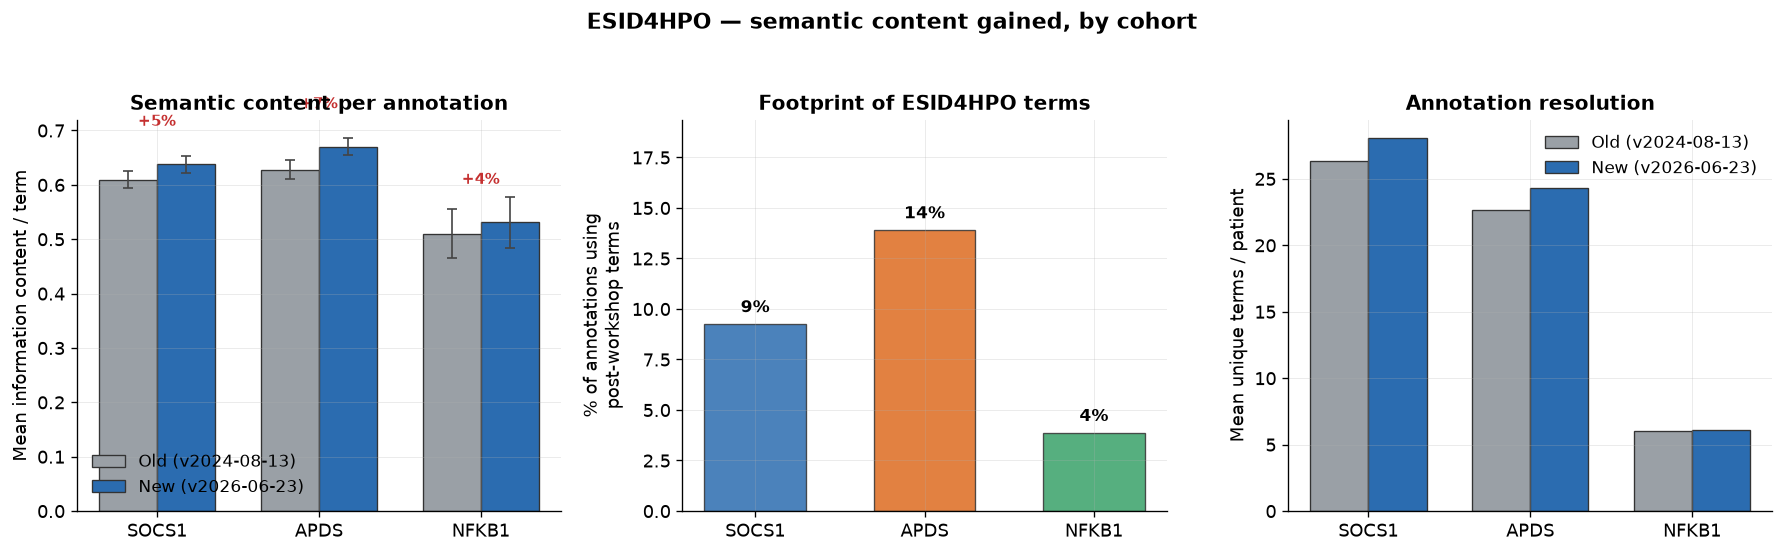

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
plot_semantic_summary(df_patient, ax=axes[0])
plot_newly_enabled(df_patient, ax=axes[1])
plot_terms_per_patient(df_patient, ax=axes[2])
fig.suptitle("ESID4HPO — semantic content gained, by cohort", fontsize=13, fontweight="bold", y=1.04)
fig.tight_layout()
fig.savefig(FPATH_FIGS / "semantic_summary.png")
fig.savefig(FPATH_FIGS / "semantic_summary.pdf")

running /Users/adamgraefe/Documents/git/esid4hpo-analysis/src/analysis/figures/fig3_panels.py
Figure 3 -> /Users/adamgraefe/Documents/git/esid4hpo-analysis/src/analysis/_work/figures


,cohort,n,n_informative,W,p_raw,rank_biserial,gain_pct,p_holm
0,SOCS1,28,24,1.0,0.0000,0.9933,4.5907,0.0000
1,APDS,38,37,0.0,0.0000,1.0000,6.6683,0.0000
2,NFKB1,21,3,0.0,0.1088,1.0000,4.1063,0.1088


  saved fig3A_paired_ic.png/.pdf/.svg  (9.60 x 4.60 in)
  saved fig3C_post_workshop_fraction.png/.pdf/.svg  (9.60 x 2.90 in)
  saved fig3D_annotation_collapse.png/.pdf/.svg  (11.60 x 3.78 in)
  collapse example: SOCS1 PMID_33087723_A2.json
Figure 3 done.


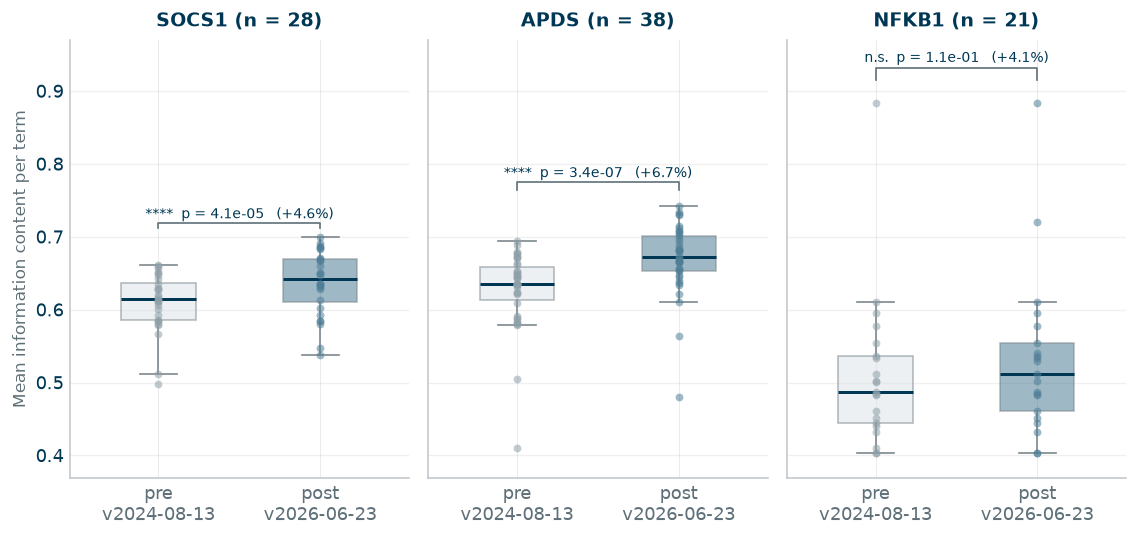

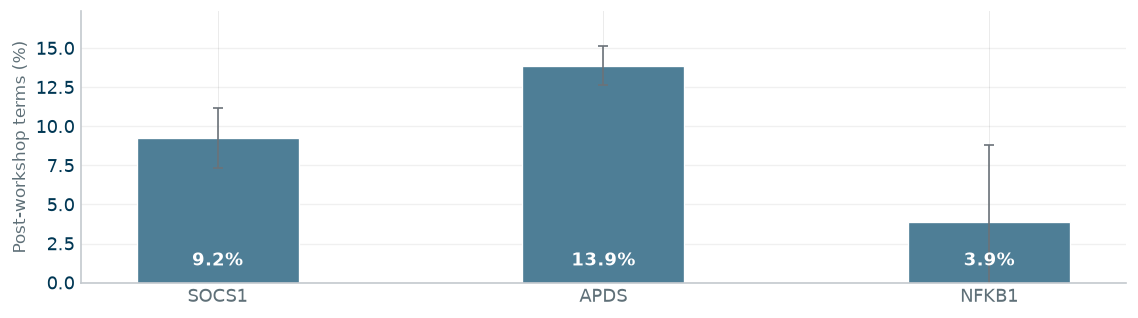

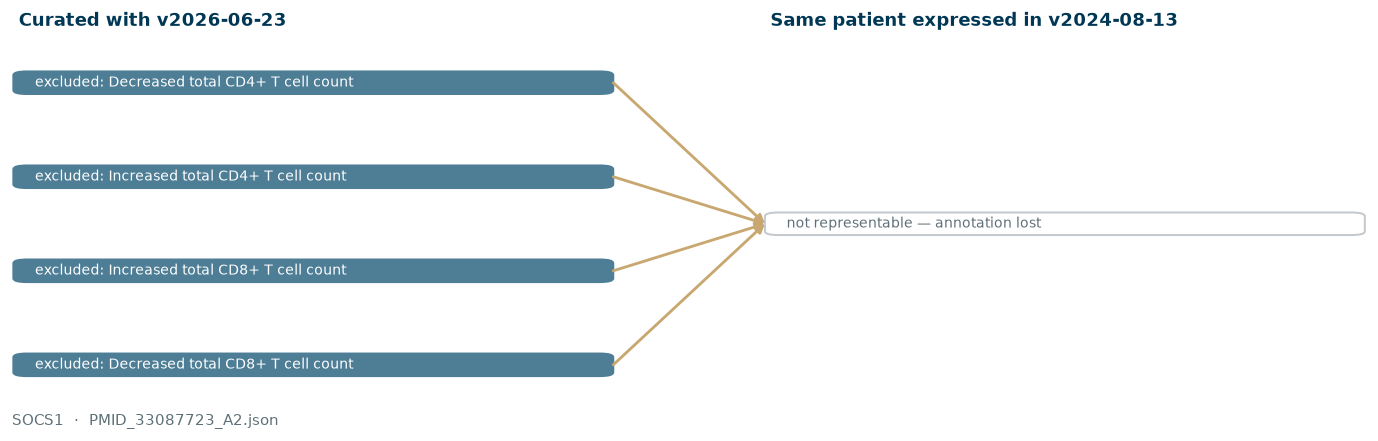

In [18]:
# ---------------------------------------------------------------
# FIGURE 3 - information content (panels A-D)
#   A  paired per-patient IC per cohort (+ Holm-corrected p-values)
#   B  cross-cohort summary bars with % gain
#   C  fraction of annotations using post-workshop terms
#   D  worked example: annotation collapse in a single patient
#
# Code lives in fig3_panels.py (plain Python, easy to edit). NFKB1 keeps a
# reserved slot until its data arrive - edit FIG3_COHORTS there to change.
# ---------------------------------------------------------------
import pathlib as _pl

_cands = [FPATH_NB / "fig3_panels.py",
          FPATH_SRC / "analysis" / "figures" / "fig3_panels.py",
          _pl.Path.cwd() / "fig3_panels.py",
          _pl.Path.cwd() / "src" / "analysis" / "figures" / "fig3_panels.py"]
FIG3_PATH = next((p for p in _cands if p.is_file()), None)
if FIG3_PATH is None:
    raise FileNotFoundError(
        "fig3_panels.py not found. Looked in:\n  " +
        "\n  ".join(str(p) for p in _cands) +
        "\nPut it next to this notebook (src/analysis/) or set FIG3_PATH manually.")
print("running", FIG3_PATH)
exec(open(FIG3_PATH).read())

## 3  Prepare phenopackets for LIRICAL

For each cohort we write two phenopacket sets:

* **new/** — the curated phenopackets, unchanged (scored with the new data bundle).
* **old/** — the *aged* phenopackets (scored with the old data bundle).

The aged phenopacket keeps the original disease/genomic interpretation but replaces the
phenotypic features with their aged CURIEs.

In [19]:
def write_aged_phenopacket(pp, hpo_old, hpo_new) -> Phenopacket:
    """Copy a phenopacket, replacing phenotypic features with aged terms (keeps excluded flag)."""
    aged = Phenopacket(); aged.CopyFrom(pp)
    aged.phenotypic_features.clear()
    mapped: dict[str, bool] = {}      # curie -> excluded (observed wins on collision)
    for pf in pp.phenotypic_features:
        g = age_feature(pf.type.id, pf.excluded, hpo_old, hpo_new)
        if g is None:
            continue
        if g in mapped:
            mapped[g] = mapped[g] and pf.excluded   # observed (False) wins
        else:
            mapped[g] = pf.excluded
    for g, exc in mapped.items():
        aged.phenotypic_features.append(PhenotypicFeature(
            type=OntologyClass(id=g, label=hpo_new.get_term_name(g)), excluded=exc))
    return aged


def stage_lirical_inputs(cohort: Cohort, hpo_old, hpo_new, root=FPATH_LIRICAL):
    new_dir = root / cohort.name / "new"; new_dir.mkdir(parents=True, exist_ok=True)
    old_dir = root / cohort.name / "old"; old_dir.mkdir(parents=True, exist_ok=True)
    n = 0
    for fname, pp in load_phenopackets(cohort.pp_dir()):
        (new_dir / fname).write_text(MessageToJson(pp))
        (old_dir / fname).write_text(MessageToJson(write_aged_phenopacket(pp, hpo_old, hpo_new)))
        n += 1
    print(f"{cohort.name:6s}  staged {n} phenopackets -> {new_dir.parent}")
    return old_dir, new_dir


for c in ACTIVE:
    stage_lirical_inputs(c, hpo_old, hpo_new)

SOCS1   staged 28 phenopackets -> /Users/adamgraefe/Documents/git/esid4hpo-analysis/src/analysis/_work/lirical/SOCS1
APDS    staged 38 phenopackets -> /Users/adamgraefe/Documents/git/esid4hpo-analysis/src/analysis/_work/lirical/APDS
NFKB1   staged 21 phenopackets -> /Users/adamgraefe/Documents/git/esid4hpo-analysis/src/analysis/_work/lirical/NFKB1


### 3.1  LIRICAL commands

LIRICAL needs a **version-matched data bundle** per release. Build them once with
`lirical prepare-resources` (or your existing bundles), pointing `data/old` at `v2024-08-13`
and `data/new` at `v2026-06-23`. The cell below prints a ready-to-run shell script.

In [20]:
lines = ["#!/usr/bin/env bash", "set -euo pipefail",
         "module load lirical/2.2.1   # or: LIRICAL=path/to/lirical",
         f'WORKDIR="{FPATH_LIRICAL}"',
         'OLD_DATA="${WORKDIR}/../data/old"   # built with ' + HPO_OLD_TAG,
         'NEW_DATA="${WORKDIR}/../data/new"   # built with ' + HPO_NEW_TAG, ""]
for c in ACTIVE:
    lines += [f'# ---- {c.name} ----',
              f'lirical benchmark -d "${{OLD_DATA}}" -o "${{WORKDIR}}/{c.name}.old.csv" "${{WORKDIR}}/{c.name}/old"/*.json',
              f'lirical benchmark -d "${{NEW_DATA}}" -o "${{WORKDIR}}/{c.name}.new.csv" "${{WORKDIR}}/{c.name}/new"/*.json', ""]
script = "\n".join(lines)
(FPATH_LIRICAL / "run_lirical.sh").write_text(script)
print(script)

#!/usr/bin/env bash
set -euo pipefail
module load lirical/2.2.1   # or: LIRICAL=path/to/lirical
WORKDIR="/Users/adamgraefe/Documents/git/esid4hpo-analysis/src/analysis/_work/lirical"
OLD_DATA="${WORKDIR}/../data/old"   # built with v2024-08-13
NEW_DATA="${WORKDIR}/../data/new"   # built with v2026-06-23

# ---- SOCS1 ----
lirical benchmark -d "${OLD_DATA}" -o "${WORKDIR}/SOCS1.old.csv" "${WORKDIR}/SOCS1/old"/*.json
lirical benchmark -d "${NEW_DATA}" -o "${WORKDIR}/SOCS1.new.csv" "${WORKDIR}/SOCS1/new"/*.json

# ---- APDS ----
lirical benchmark -d "${OLD_DATA}" -o "${WORKDIR}/APDS.old.csv" "${WORKDIR}/APDS/old"/*.json
lirical benchmark -d "${NEW_DATA}" -o "${WORKDIR}/APDS.new.csv" "${WORKDIR}/APDS/new"/*.json

# ---- NFKB1 ----
lirical benchmark -d "${OLD_DATA}" -o "${WORKDIR}/NFKB1.old.csv" "${WORKDIR}/NFKB1/old"/*.json
lirical benchmark -d "${NEW_DATA}" -o "${WORKDIR}/NFKB1.new.csv" "${WORKDIR}/NFKB1/new"/*.json



## 4  LIRICAL evaluation

Run `_work/lirical/run_lirical.sh`, then load the CSVs below. The next cell tolerates missing
files so you can develop the notebook before LIRICAL has finished.

In [21]:
rank_tables, rank_long_rows = {}, []
for c in ACTIVE:
    old_csv = FPATH_LIRICAL / f"{c.name}.old.csv"
    new_csv = FPATH_LIRICAL / f"{c.name}.new.csv"
    if not (old_csv.exists() and new_csv.exists()):
        print(f"{c.name:6s}  (LIRICAL output not found yet - run run_lirical.sh)")
        continue
    rt = lirical_rank_table(old_csv, new_csv)
    rank_tables[c.name] = rt
    for fname, row in rt.dropna().iterrows():
        rank_long_rows.append(dict(cohort=c.name, phenopacket=fname, version="old", rank=row["old"]))
        rank_long_rows.append(dict(cohort=c.name, phenopacket=fname, version="new", rank=row["new"]))

df_ranks = pd.DataFrame(rank_long_rows)
print("loaded cohorts:", list(rank_tables))

loaded cohorts: ['SOCS1', 'APDS', 'NFKB1']


### 4.1  Rank table & improvement stats

In [22]:
if rank_tables:
    rows = []
    for ch, rt in rank_tables.items():
        d = rt.dropna()
        improved = (d["new"] < d["old"]).sum()
        worse    = (d["new"] > d["old"]).sum()
        line = dict(cohort=ch, n=len(d),
                    median_old=d["old"].median(), median_new=d["new"].median(),
                    top1_old=(d["old"] <= 1).mean()*100, top1_new=(d["new"] <= 1).mean()*100,
                    top10_old=(d["old"] <= 10).mean()*100, top10_new=(d["new"] <= 10).mean()*100,
                    improved=improved, worse=worse)
        if HAVE_SCIPY and len(d) >= 5 and (d["new"] - d["old"]).abs().sum() > 0:
            line["wilcoxon_p"] = wilcoxon(d["new"], d["old"]).pvalue
        rows.append(line)
    display(pd.DataFrame(rows).round(2))
else:
    print("No LIRICAL results loaded yet.")

,cohort,n,median_old,median_new,top1_old,top1_new,top10_old,top10_new,improved,worse,wilcoxon_p
0,SOCS1,18,455.5,2.0,0.00,44.44,0.00,94.44,18,0,0.00
1,APDS,38,38.5,1.0,7.89,78.95,34.21,100.00,33,0,0.00
2,NFKB1,21,55.0,57.0,4.76,4.76,23.81,23.81,4,12,0.27


### 4.2  Figures — LIRICAL

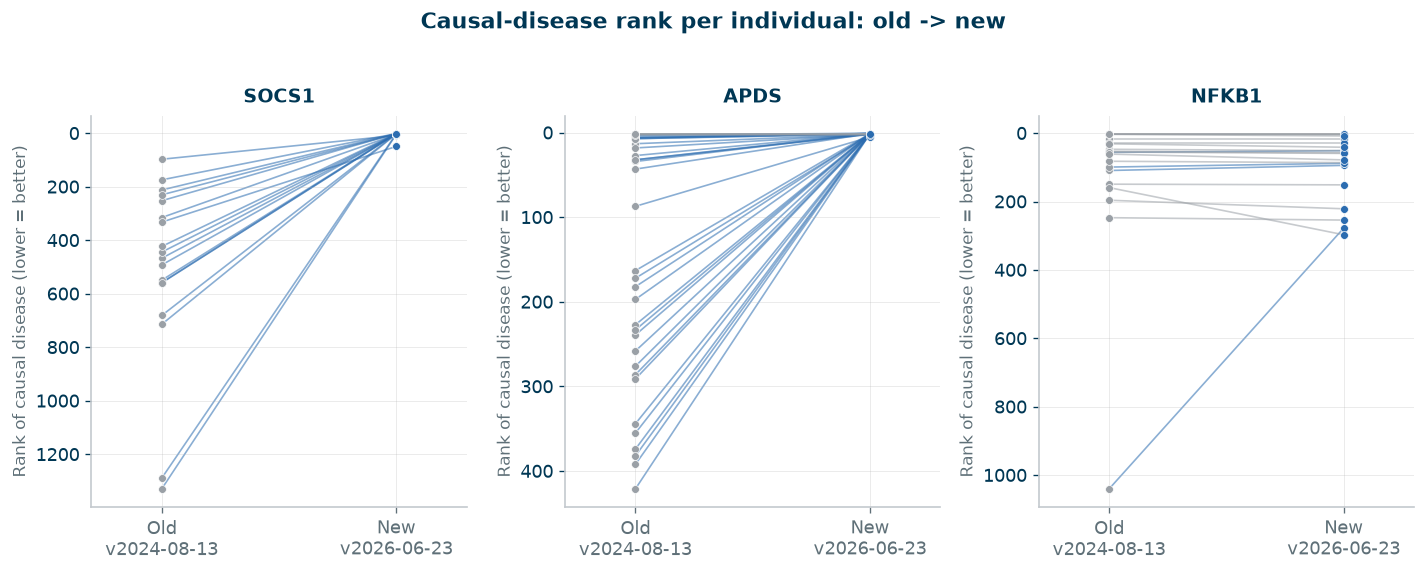

In [23]:
if rank_tables:
    n = len(rank_tables)
    fig, axes = plt.subplots(1, n, figsize=(4.0 * n, 4.6), squeeze=False)
    for ax, (ch, rt) in zip(axes[0], rank_tables.items()):
        plot_lirical_slope(rt, ch, ax=ax)
    fig.suptitle("Causal-disease rank per individual: old -> new",
                 fontsize=13, fontweight="bold", y=1.03)
    fig.tight_layout()
    fig.savefig(FPATH_FIGS / "lirical_per_cohort.png")

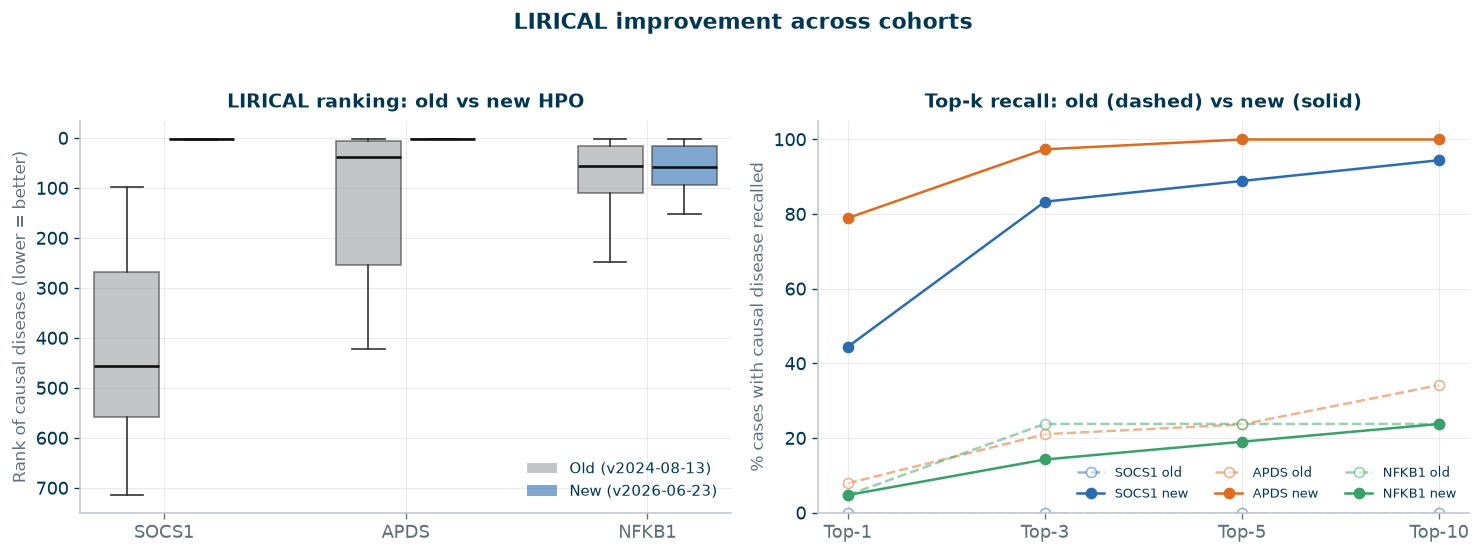

In [24]:
if not df_ranks.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
    plot_lirical_summary_box(df_ranks, ax=axes[0])
    plot_topk_recall(df_ranks, ax=axes[1])
    fig.suptitle("LIRICAL improvement across cohorts",
                 fontsize=13, fontweight="bold", y=1.04)
    fig.tight_layout()
    fig.savefig(FPATH_FIGS / "lirical_summary.png")
    fig.savefig(FPATH_FIGS / "lirical_summary.pdf")

## 5  Export tables

In [25]:
df_patient.to_csv(FPATH_WORK / "semantic_patient_level.csv", index=False)
df_terms.to_csv(FPATH_WORK / "semantic_term_level.csv", index=False)
summary.to_csv(FPATH_WORK / "semantic_summary.csv")
if not df_ranks.empty:
    df_ranks.to_csv(FPATH_WORK / "lirical_ranks_long.csv", index=False)
print("Wrote tables and figures to", FPATH_WORK)

Wrote tables and figures to /Users/adamgraefe/Documents/git/esid4hpo-analysis/src/analysis/_work


*— EOF —*